# Analysis — Finite A2 Element Classification

1-layer causal model classifying, at every prefix of a random word over the two generators of finite A2 (= S3), **which of the 6 group elements** the prefix equals. Softmax cross-entropy over element IDs 0..5 (ShortLex order: e, 1, 2, 12, 21, 121). Run cells top-to-bottom after `workspace/_scratch/model.pth` exists.


# Setup


In [1]:
!echo $HOSTNAME


g006


In [2]:
import sys, os, math, ast
sys.path.insert(0, os.getcwd())   # so config.py / Transformer.py import from this folder

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"


In [3]:
# transformer_lens unpickling shim (checkpoints saved by a version that pickled
# the config under a module path newer installs renamed).
import transformer_lens
try:
    import transformer_lens.config.hooked_transformer_config as htc
    sys.modules.setdefault('transformer_lens.HookedTransformerConfig', htc)
except ImportError:
    pass


In [ ]:
# --- Which run to analyze -------------------------------------------
# Point this at the arm/extension folder holding the config.py and the
# workspace/_scratch/model.pth you want to inspect. This notebook is for
# the cross-entropy (classification / sequence-output) runs.
ARM_DIR = "../extensions/element_classification"
# ---------------------------------------------------------------------

from pathlib import Path

_ARM = Path(ARM_DIR).resolve()
assert (_ARM / "config.py").is_file(), f"no config.py in {_ARM}"
sys.path.insert(0, str(_ARM))   # config.py for the chosen run
print("Analyzing:", _ARM)       # (cell above already put shared/ on sys.path)

from config import *
from Transformer_classification import (
    setup_device, build_model, load_checkpoint_into, load_train_test_data,
    class_loss_fn, class_accuracy_fn, class_sequence_accuracy_fn,
    create_attention_mask, register_pad_mask_hook,
)

In [5]:
device, device1 = setup_device()


CUDA available: True
Device count: 1
Device 0: NVIDIA A100-PCIE-40GB
Device Name: cuda


## Load Checkpoint


In [6]:
torch.manual_seed(seed=DATA_SEED)
torch.cuda.manual_seed_all(DATA_SEED)

cached_data = torch.load(PTH_LOCATION, weights_only=False)
cfg = cached_data["config"]
model, optimizer, scheduler = build_model(cfg)
_, history = load_checkpoint_into(model, optimizer, scheduler)

checkpoint_epochs = history["checkpoint_epochs"]
train_losses, test_losses = history["train_losses"], history["test_losses"]
train_accuracies, test_accuracies = history["train_accuracies"], history["test_accuracies"]
train_seq_accuracies, test_seq_accuracies = history["train_seq_accuracies"], history["test_seq_accuracies"]

torch.set_grad_enabled(False)
print(f"{len(checkpoint_epochs)} checkpoints, final epoch {checkpoint_epochs[-1]}")


100 checkpoints, final epoch 9900


## Load Data


In [7]:
data = load_train_test_data(device1)
train_tokens, test_tokens = data["train_tokens"], data["test_tokens"]
train_targets, test_targets = data["train_targets"], data["test_targets"]
train_mask, test_mask = data["train_mask"], data["test_mask"]


Loaded dataset: tokens (1200, 18) | targets (1200, 18)
Loaded dataset: tokens (2800, 18) | targets (2800, 18)
Train size: 1200 | Test size: 2800 | Seq Len: 18


# Training Curves


In [18]:
from neel_plotly.plot import line_or_scatter

skipBy = 1
def createGraph(yTrain, yTest, yName, title):
    yTrain = [float(v) for v in yTrain]
    yTest = [float(v) for v in yTest]
    return line_or_scatter([yTrain[::skipBy], yTest[::skipBy]],
        x=np.array(checkpoint_epochs[::skipBy]), xaxis="Epoch", yaxis=yName,
        log_y=True, title=title, line_labels=['train', 'test'],
        toggle_x=True, toggle_y=True, plot_type="line", return_fig=True)

fig1 = createGraph(train_losses, test_losses, "Loss", "Loss Curve — Finite A2 Element Classification")
fig2 = createGraph(train_accuracies, test_accuracies, "Per-Position Accuracy", "Per-Position Accuracy Curve")
fig3 = createGraph(train_seq_accuracies, test_seq_accuracies, "Whole-Word Accuracy", "Whole-Word Accuracy Curve")
fig1.show(); fig2.show(); fig3.show()
fig1.write_html("1. loss_curve.html")
fig2.write_html("2. accuracy_curve.html")
fig3.write_html("3. seq_accuracy.html")


# Helper Functions


In [9]:
def getLogits(model, tokens, getCache=False):
    """Forward pass with the padding-attention hook registered (the training idiom)."""
    model.reset_hooks()
    register_pad_mask_hook(model, create_attention_mask(tokens))
    with torch.inference_mode():
        if getCache:
            return model.run_with_cache(tokens)
        return model(tokens)

def imshow(tensor, xlabel="x", ylabel="y", title="", x=None, y=None,
           color_continuous_scale="Blues", **kwargs):
    arr = tensor.detach().cpu().numpy() if torch.is_tensor(tensor) else np.array(tensor)
    px.imshow(arr, labels=dict(x=xlabel, y=ylabel), x=x, y=y, title=title,
              color_continuous_scale=color_continuous_scale, **kwargs).show()


# Confusion Matrix (test)

Rows are the true element, columns the predicted element, row-normalized. Off-diagonal structure shows *which* group elements get confused — e.g. whether errors respect cosets or word length.


In [10]:
CLASS_NAMES = ["e", "1", "2", "12", "21", "121"]

test_logits = getLogits(model, test_tokens)
test_preds = test_logits.argmax(dim=-1)
m = test_mask.bool()

conf = torch.zeros(DIM_OUTPUT, DIM_OUTPUT)
for t, p in zip(test_targets[m].tolist(), test_preds[m].tolist()):
    conf[t, p] += 1
conf_norm = conf / conf.sum(dim=1, keepdim=True).clamp(min=1)

overall = (test_preds[m] == test_targets[m]).float().mean()
imshow(conf_norm, xlabel="predicted", ylabel="true", x=CLASS_NAMES, y=CLASS_NAMES,
       title=f"Test element confusion (row-normalized) — overall acc {overall:.4f}")
print(conf.long())


tensor([[8838,    0,    0,    6,   10,    0],
        [   0, 8871,   23,    0,    0,    7],
        [   0,    9, 8949,    0,    0,    4],
        [  11,    0,    0, 8114,   12,    0],
        [   6,    0,    0,    0, 8203,    0],
        [   0,    3,   17,    0,    0, 7317]])


# Error Rate by Position

Every position 1..18 is a real letter (fixed-length words, no padding). Errors concentrated at later positions would indicate state-tracking degradation with depth.


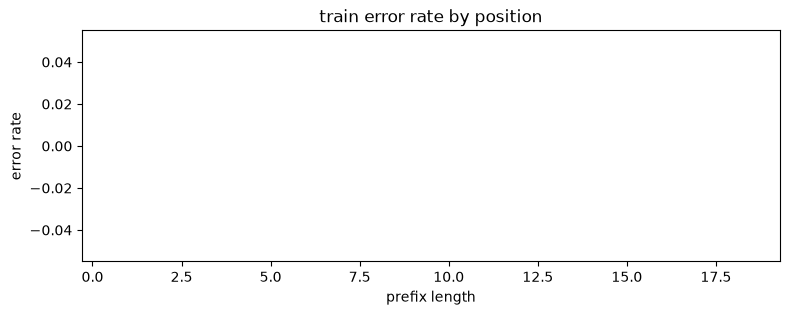

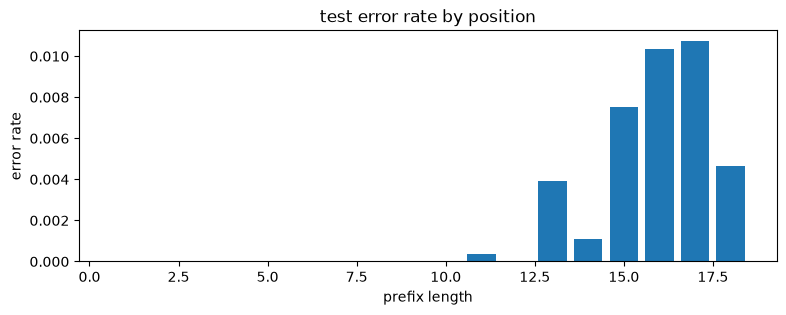

In [11]:
def position_error_rates(logits, targets, mask):
    wrong = ((logits.argmax(dim=-1) != targets) & mask.bool()).float().sum(dim=0)
    total = mask.float().sum(dim=0)
    return (wrong / total.clamp(min=1)).cpu().numpy()

for name, tok, tgt, msk in [("train", train_tokens, train_targets, train_mask),
                            ("test", test_tokens, test_targets, test_mask)]:
    rates = position_error_rates(getLogits(model, tok), tgt, msk)
    plt.figure(figsize=(9, 3))
    plt.bar(np.arange(len(rates)) + 1, rates)
    plt.xlabel("prefix length"); plt.ylabel("error rate")
    plt.title(f"{name} error rate by position")
    plt.show()


In [12]:
wrong_rows = ((test_preds != test_targets) & m).any(dim=1).nonzero().flatten().tolist()
print(f"{len(wrong_rows)} of {test_tokens.shape[0]} test words have >= 1 wrong prefix")
for r in wrong_rows[:5]:
    word = test_tokens[r][m[r]].tolist()
    print("word", word)
    print("  true", [CLASS_NAMES[i] for i in test_targets[r][m[r]].tolist()])
    print("  pred", [CLASS_NAMES[i] for i in test_preds[r][m[r]].tolist()])


67 of 2800 test words have >= 1 wrong prefix
word [2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1]
  true ['2', 'e', '2', 'e', '2', '21', '121', '21', '121', '21', '121', '21', '121', '21', '121', '21', '2', '21']
  pred ['2', 'e', '2', 'e', '2', '21', '121', '21', '121', '21', '121', '21', '121', '21', '2', 'e', '1', '21']
word [2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1]
  true ['2', '21', '121', '21', '121', '21', '121', '21', '121', '21', '121', '21', '121', '21', '2', '21', '121', '12']
  pred ['2', '21', '121', '21', '121', '21', '121', '21', '121', '21', '121', '21', '121', '21', '1', '21', '121', '12']
word [2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2]
  true ['2', '21', '121', '12', '1', '12', '1', '12', '1', 'e', '2', '21', '121', '12', '1', '12', '1', '12']
  pred ['2', '21', '121', '12', '1', '12', '1', '12', '1', 'e', '2', '21', '121', '12', '1', '12', '121', '12']
word [1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2]
  true ['1', 'e', '1', '

# Attention Patterns

Positional embeddings are **standard learned absolute** (`POSITIONAL_EMBEDDING_TYPE = "standard"`), attention is causal, and padding keys are masked by the same hook used in training.


In [13]:
N_SUB = min(512, test_tokens.shape[0])
_, cache_sub = getLogits(model, test_tokens[:N_SUB], getCache=True)
avg_pattern = cache_sub["pattern", 0].mean(dim=0)   # [heads, query, key]
for h in range(avg_pattern.shape[0]):
    imshow(avg_pattern[h], xlabel="key (attended to)", ylabel="query",
           title=f"Layer 0 head {h} — mean attention over {N_SUB} test words")


In [14]:
r = 0
_, cache_w = getLogits(model, test_tokens[r:r+1], getCache=True)
sample_word = test_tokens[r][test_mask[r].bool()].tolist()
print("sample word:", sample_word)
for h in range(cache_w["pattern", 0].shape[1]):
    imshow(cache_w["pattern", 0][0, h], xlabel="key", ylabel="query",
           title=f"head {h} — attention on sample word")


sample word: [2, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 1, 1]


# Automaton-State PCA

The model must carry the current S3 element in its residual stream. If it implements the 6-state automaton, `resid_post` states should separate into 6 clusters when colored by the true element of the prefix.


In [15]:
def pca_2d(X):
    """Plain-SVD 2-component PCA (no sklearn dependency). Returns (XY, evr)."""
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    return Xc @ Vt[:2].T, float((S[:2] ** 2).sum() / (S ** 2).sum())


In [16]:
resid = cache_sub["resid_post", 0]                    # [batch, pos, d_model]
sub_mask = test_mask[:N_SUB].bool()
X = resid[sub_mask].cpu().numpy()
labels = test_targets[:N_SUB][sub_mask].cpu().numpy()

XY, evr = pca_2d(X)
fig = px.scatter(x=XY[:, 0], y=XY[:, 1], color=[CLASS_NAMES[i] for i in labels],
                 labels=dict(x="PC1", y="PC2", color="element"),
                 title=f"resid_post PCA colored by true element (2-PC explained var {evr:.2f})")
fig.update_traces(marker=dict(size=3, opacity=0.5))
fig.show()
